# Modular RCA Log Analysis Notebook

Run this notebook from top to bottom, or rerun individual sections as needed. Each code cell is a small module that either defines reusable pieces or shows the result of one stage.

In [43]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
pwd

'/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline'

## Imports and Configuration

This cell loads dependencies, `.env` values, and the folder paths used by the workflow.

In [1]:
import json
import os
import sys
import time
from copy import deepcopy
from pathlib import Path
from pprint import pprint

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from IPython.display import JSON, Markdown, display

from agno.agent import Agent
from agno.models.openai.like import OpenAILike
from agno.knowledge.knowledge import Knowledge
from agno.knowledge.embedder.openai_like import OpenAILikeEmbedder
from agno.vectordb.chroma import ChromaDb

from openai import OpenAI

DEFAULT_KG_PROJECT_ROOT = Path(
    "/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline"
)

cwd = Path.cwd().resolve()
if (cwd / "models.py").exists() and (cwd / "agent_instructions.xlsx").exists():
    KG_NOTEBOOK_FOLDER = cwd
    KG_PROJECT_ROOT = cwd.parent
elif (cwd / "notebook" / "models.py").exists() and (cwd / "notebook" / "agent_instructions.xlsx").exists():
    KG_PROJECT_ROOT = cwd
    KG_NOTEBOOK_FOLDER = cwd / "notebook"
else:
    KG_PROJECT_ROOT = DEFAULT_KG_PROJECT_ROOT
    KG_NOTEBOOK_FOLDER = KG_PROJECT_ROOT / "notebook"

if str(KG_NOTEBOOK_FOLDER) not in sys.path:
    sys.path.insert(0, str(KG_NOTEBOOK_FOLDER))

from models import ExtractedRCA, MatchResult

load_dotenv(dotenv_path=KG_PROJECT_ROOT / ".env")
load_dotenv(dotenv_path=KG_NOTEBOOK_FOLDER / ".env")

PROCESSED_FOLDER = KG_PROJECT_ROOT / "data/processed_logs"
NEW_FOLDER = KG_PROJECT_ROOT / "data/new_logs"
ONTOLOGY_JSON_FILE = KG_NOTEBOOK_FOLDER / "ontology/RCA_Ontology_Pydantic_Specification.json"
AGENT_INSTRUCTIONS_FILE = KG_NOTEBOOK_FOLDER / "agent_instructions.xlsx"
OUTPUT_FOLDER = KG_PROJECT_ROOT / "data" / "output"
CHROMA_DB_PATH = OUTPUT_FOLDER / "chroma_rca_kg"
INTERMEDIATE_OUTPUT_FOLDER = OUTPUT_FOLDER / "intermediate"

AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_INFERENCE_ENDPOINT", "https://aaii-ai-foundry.services.ai.azure.com/openai/v1")
AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4.1")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "text-embedding-3-small")
OPENAI_API_TIMEOUT = float(os.getenv("OPENAI_API_TIMEOUT", "600"))
OPENAI_MAX_RETRIES = int(os.getenv("OPENAI_MAX_RETRIES", "4"))
EXTRACT_MAX_ATTEMPTS = int(os.getenv("EXTRACT_MAX_ATTEMPTS", "3"))
EXTRACT_RETRY_DELAY_SECONDS = float(os.getenv("EXTRACT_RETRY_DELAY_SECONDS", "10"))
USE_AGENT_RUN_FOR_TOOLS = os.getenv("USE_AGENT_RUN_FOR_TOOLS", "false").lower() in {"1", "true", "yes"}

OUTPUT_FOLDER.mkdir(exist_ok=True)
INTERMEDIATE_OUTPUT_FOLDER.mkdir(exist_ok=True)

PATHS = {
    "kg_project_root": KG_PROJECT_ROOT,
    "kg_notebook_folder": KG_NOTEBOOK_FOLDER,
    "processed_folder": PROCESSED_FOLDER,
    "new_folder": NEW_FOLDER,
    "ontology_JSON_file": ONTOLOGY_JSON_FILE,
    "agent_instructions_file": AGENT_INSTRUCTIONS_FILE,
    "output_folder": OUTPUT_FOLDER,
    "chroma_db_path": CHROMA_DB_PATH,
    "intermediate_output_folder": INTERMEDIATE_OUTPUT_FOLDER,
}

display(Markdown("### Configured paths"))
pprint({name: str(path) for name, path in PATHS.items()})


### Configured paths

{'agent_instructions_file': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied '
                            'AI '
                            'Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/notebook/agent_instructions.xlsx',
 'chroma_db_path': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI '
                   'Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/chroma_rca_kg',
 'intermediate_output_folder': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied '
                               'AI '
                               'Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate',
 'kg_notebook_folder': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI '
                       'Institute/Clients/Qua

## 1. Set up Agent Instructions and Tools

In [24]:
agent_instructions_df = pd.read_excel(
    AGENT_INSTRUCTIONS_FILE,
    sheet_name="Agent Instructions",
)

required_agent_keys = [
    "extract",
    "match",
    "ontology_loader",
    "historical_extraction",
    "embedding",
    "similarity",
    "clustering",
    "kg_consistency",
    "kg_persistence",
]

missing_agent_keys = sorted(
    set(required_agent_keys) - set(agent_instructions_df["agent_key"].dropna())
)
if missing_agent_keys:
    raise ValueError(
        "Missing required rows in agent_instructions.xlsx sheet 'Agent Instructions': "
        + ", ".join(missing_agent_keys)
    )


def get_agent_config(agent_key):
    """Read one agent's name and instructions from agent_instructions.xlsx."""
    return agent_instructions_df[
        agent_instructions_df["agent_key"] == agent_key
    ].iloc[0]


extract_row = get_agent_config("extract")
match_row = get_agent_config("match")
ontology_loader_row = get_agent_config("ontology_loader")
historical_extraction_row = get_agent_config("historical_extraction")
embedding_row = get_agent_config("embedding")
similarity_row = get_agent_config("similarity")
clustering_row = get_agent_config("clustering")
kg_consistency_row = get_agent_config("kg_consistency")
kg_persistence_row = get_agent_config("kg_persistence")

client = OpenAI(
    base_url=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    timeout=OPENAI_API_TIMEOUT,
    max_retries=OPENAI_MAX_RETRIES,
)

model = OpenAILike(
    id=LLM_MODEL,
    base_url=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    timeout=OPENAI_API_TIMEOUT,
    max_retries=OPENAI_MAX_RETRIES,
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

rca_kg_embedder = OpenAILikeEmbedder(
    id=EMBEDDING_MODEL,
    base_url=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    client_params={
        "timeout": OPENAI_API_TIMEOUT,
        "max_retries": OPENAI_MAX_RETRIES,
    },
)

rca_kg_vector_db = ChromaDb(
    collection="rca_knowledge_graph",
    path=str(CHROMA_DB_PATH),
    persistent_client=True,
    embedder=rca_kg_embedder,
)

rca_kg_knowledge = Knowledge(
    name="RCA Knowledge Graph",
    description="Symptom, Root Cause, Data Gap, Preventive Action, and Remediation knowledge extracted from historical RCA logs.",
    vector_db=rca_kg_vector_db,
)

extract_agent = Agent(
    name=extract_row["agent_name"],
    model=model,
    output_schema=ExtractedRCA,
    instructions=extract_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

match_agent = Agent(
    name=match_row["agent_name"],
    model=model,
    output_schema=MatchResult,
    instructions=match_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)


def as_extracted_rca(value):
    """Validate any RCA JSON/dict/model value against models.ExtractedRCA."""
    if isinstance(value, ExtractedRCA):
        return value
    if isinstance(value, str):
        return ExtractedRCA.model_validate_json(value)
    return ExtractedRCA.model_validate(value)


def extracted_rca_json(value):
    """Return canonical JSON that conforms to models.ExtractedRCA."""
    return as_extracted_rca(value).model_dump_json()


def extracted_rca_dict(value):
    """Return a dict that conforms to models.ExtractedRCA."""
    return as_extracted_rca(value).model_dump()


def to_jsonable(value):
    """Convert common notebook objects into JSON-serializable structures."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, set):
        return sorted(to_jsonable(item) for item in value)
    if isinstance(value, tuple):
        return [to_jsonable(item) for item in value]
    if isinstance(value, list):
        return [to_jsonable(item) for item in value]
    if isinstance(value, dict):
        return {str(key): to_jsonable(item) for key, item in value.items()}
    if isinstance(value, np.ndarray):
        return value.tolist()
    if hasattr(value, "model_dump"):
        return to_jsonable(value.model_dump())
    return value


def save_intermediate_result(name, value):
    """Save one intermediate result to output/intermediate as JSON."""
    INTERMEDIATE_OUTPUT_FOLDER.mkdir(exist_ok=True)
    output_path = INTERMEDIATE_OUTPUT_FOLDER / f"{name}.json"
    output_path.write_text(
        json.dumps(to_jsonable(value), indent=2),
        encoding="utf-8",
    )
    print(f"Saved intermediate result: {output_path}")
    return output_path


def find_agent_tool(agent, tool_name):
    """Find a callable tool attached to an Agent by function name."""
    for tool in agent.tools or []:
        if getattr(tool, "__name__", None) == tool_name:
            return tool
    raise ValueError(f"Tool {tool_name} is not attached to agent {agent.name}.")


def forced_tool_choice(tool_name):
    """Return an OpenAI-compatible tool_choice object for one Agno tool."""
    return {"type": "function", "function": {"name": tool_name}}


def run_agent_tool(agent, tool_name, prompt, result_name=None, checkpoint_name=None, tool_kwargs=None):
    """Run one agent-owned tool, fast by default, with optional full Agent.run orchestration.

    USE_AGENT_RUN_FOR_TOOLS=false avoids an LLM round trip for deterministic local tools.
    Set USE_AGENT_RUN_FOR_TOOLS=true if you explicitly want the LLM to invoke the tool.
    """
    tool_kwargs = tool_kwargs or {}
    if USE_AGENT_RUN_FOR_TOOLS:
        previous_tool_choice = agent.tool_choice
        agent.tool_choice = forced_tool_choice(tool_name)
        try:
            response = agent.run(prompt)
        finally:
            agent.tool_choice = previous_tool_choice
        result = globals()[result_name] if result_name is not None else response
    else:
        tool = find_agent_tool(agent, tool_name)
        result = tool(**tool_kwargs)
        if result_name is not None:
            globals()[result_name] = result

    if checkpoint_name is None:
        checkpoint_name = result_name
    if checkpoint_name is not None:
        save_intermediate_result(checkpoint_name, result)
    return result


def load_ontology_tool():
    """Load the RCA ontology JSON file."""
    global ontology_json
    with open(ONTOLOGY_JSON_FILE) as file:
        ontology_json = json.load(file)
    return ontology_json


def discover_processed_logs_tool():
    """Discover processed RCA log text files."""
    global processed_log_files
    processed_log_files = os.listdir(PROCESSED_FOLDER)
    return processed_log_files

def discover_new_logs_tool():
    """Discover new RCA log text files."""
    global new_log_files
    new_log_files = os.listdir(NEW_FOLDER)
    return new_log_files


def is_transient_agent_error_content(content):
    """Detect text responses that are API failures, not ExtractedRCA JSON."""
    if not isinstance(content, str):
        return False
    normalized = content.strip().lower()
    transient_markers = [
        "request timed out",
        "operation cancelled",
        "api connection error",
        "timeout",
        "timed out",
    ]
    return any(marker in normalized for marker in transient_markers)


def extract_rca_with_retries(prompt, log_filename):
    """Run extract_agent with retries and validate only real ExtractedRCA output."""
    last_error = None
    for attempt in range(1, EXTRACT_MAX_ATTEMPTS + 1):
        try:
            response = extract_agent.run(prompt)
            content = response.content
            if is_transient_agent_error_content(content):
                raise TimeoutError(content)
            return as_extracted_rca(content)
        except Exception as e:
            last_error = e
            if attempt < EXTRACT_MAX_ATTEMPTS:
                print(
                    f"Retrying {log_filename} after extraction error "
                    f"({attempt}/{EXTRACT_MAX_ATTEMPTS}): {e}"
                )
                time.sleep(EXTRACT_RETRY_DELAY_SECONDS * attempt)
            else:
                raise RuntimeError(
                    f"Extraction failed for {log_filename} after {EXTRACT_MAX_ATTEMPTS} attempts: {e}"
                ) from last_error


def extract_processed_rca_logs_tool():
    """Extract processed RCA logs into the ExtractedRCA Pydantic schema."""
    global processed_log_files, processed_jsons
    processed_log_files = [
        filename for filename in os.listdir(PROCESSED_FOLDER) if filename.endswith(".txt")
    ]
    processed_jsons = []

    for log_filename in processed_log_files:
        try:
            log_path = PROCESSED_FOLDER / log_filename

            with open(log_path, "r", encoding="utf-8") as file:
                log_text = file.read()

            prompt = f"""
    Source file:
    {log_filename}

    RCA log:
    {log_text}
    """

            extracted_rca = extract_rca_with_retries(prompt, log_filename)
            processed_jsons.append(
                {
                    "file_name": log_filename,
                    "log_text": log_text,
                    "log_json": extracted_rca.model_dump_json(),
                }
            )
        except Exception as e:
            print(f"Error processing {log_filename}: {e}")

    return processed_jsons

def extract_new_rca_logs_tool():
    """Extract processed RCA logs into the ExtractedRCA Pydantic schema."""
    global new_log_files, new_jsons
    new_log_files = [
        filename for filename in os.listdir(NEW_FOLDER) if filename.endswith(".txt")
    ]
    new_jsons = []

    for log_filename in new_log_files:
        try:
            log_path = NEW_FOLDER / log_filename

            with open(log_path, "r", encoding="utf-8") as file:
                log_text = file.read()

            prompt = f"""
    Source file:
    {log_filename}

    RCA log:
    {log_text}
    """

            extracted_rca = extract_rca_with_retries(prompt, log_filename)
            new_jsons.append(
                {
                    "file_name": log_filename,
                    "log_text": log_text,
                    "log_json": extracted_rca.model_dump_json(),
                }
            )
        except Exception as e:
            print(f"Error processing {log_filename}: {e}")

    return new_jsons


def save_processed_rca_json_list_tool():
    """Save extracted processed RCA JSON records to disk after Pydantic validation."""
    global processed_output_file
    for processed_json in processed_jsons:
        processed_json["log_json"] = extracted_rca_json(processed_json["log_json"])

    processed_output_file = OUTPUT_FOLDER / "processed_rca_json_list.json"
    processed_output_file.write_text(
        json.dumps(processed_jsons, indent=2),
        encoding="utf-8",
    )
    return str(processed_output_file)

def save_new_rca_json_list_tool():
    """Save extracted new RCA JSON records to disk after Pydantic validation."""
    global new_output_file
    for new_json in new_jsons:
        new_json["log_json"] = extracted_rca_json(new_json["log_json"])

    new_output_file = OUTPUT_FOLDER / "new_rca_json_list.json"
    new_output_file.write_text(
        json.dumps(new_jsons, indent=2),
        encoding="utf-8",
    )
    return str(new_output_file)


def load_processed_rca_json_list_tool():
    """Load extracted processed RCA JSON records from disk and validate with ExtractedRCA."""
    global processed_jsons
    with open(OUTPUT_FOLDER / "processed_rca_json_list.json", "r") as json_file:
        processed_jsons = json.load(json_file)

    for processed_json in processed_jsons:
        processed_json["log_json"] = extracted_rca_json(processed_json["log_json"])
    return processed_jsons

def load_new_rca_json_list_tool():
    """Load extracted new RCA JSON records from disk and validate with ExtractedRCA."""
    global new_jsons
    with open(OUTPUT_FOLDER / "new_rca_json_list.json", "r") as json_file:
        new_jsons = json.load(json_file)

    for new_json in new_jsons:
        new_json["log_json"] = extracted_rca_json(new_json["log_json"])
    return new_jsons


def display_srd_tool():
    """Print symptom, root cause, and data gap fields for extracted RCA logs."""
    for processed_json in processed_jsons:
        log_json = extracted_rca_dict(processed_json["log_json"])
        print("Log symptoms: ", log_json["log_symptoms"])
        print("Root Causes: ", log_json["root_causes"])
        print("Data Gaps: ", log_json["data_gaps"])
    return "Displayed symptom/root cause/data gap values."


def create_embedding_vectors_tool():
    """Create embedding vectors from Pydantic-valid log symptoms, root causes, and data gaps."""
    print("Starting vectorization loop...")

    for i in range(0, len(processed_jsons)):
        log_json = extracted_rca_dict(processed_jsons[i]["log_json"])
        embedding_text = f"""Log symptoms:  {log_json['log_symptoms']}
    \n Root Causes:  {log_json['root_causes']}
    \n Data Gaps:  {log_json['data_gaps']}"""
        print(f"Processing log file {i + 1}/{len(processed_jsons)}: {embedding_text}")
        response = client.embeddings.create(
            input=embedding_text,
            model=EMBEDDING_MODEL,
        )

        processed_jsons[i]["log_json"] = extracted_rca_json(processed_jsons[i]["log_json"])
        processed_jsons[i]["embedding_text"] = embedding_text
        processed_jsons[i]["embedding_text_vector"] = response.data[0].embedding

    print("All log files now contain embedding vectors.")
    return processed_jsons


def create_similarity_pairs_tool():
    """Create all pairwise similarity scores from embedding vectors."""
    global similarity_pairs
    similarity_pairs = []

    for i in range(len(processed_jsons)):
        for j in range(i + 1, len(processed_jsons)):
            vec_a = processed_jsons[i]["embedding_text_vector"]
            vec_b = processed_jsons[j]["embedding_text_vector"]
            score = np.dot(vec_a, vec_b)

            comparison = {
                "log_file_a": processed_jsons[i]["embedding_text"],
                "log_file_b": processed_jsons[j]["embedding_text"],
                "similarity": round(float(score), 4),
                "index_a": i,
                "index_b": j,
            }
            similarity_pairs.append(comparison)

    print(f"Generated {len(similarity_pairs)} total comparison pairs.")
    return similarity_pairs


def analyze_similarity_scores_tool():
    """Analyze and visualize the similarity score distribution."""
    all_scores = [pair["similarity"] for pair in similarity_pairs]

    mean_score = np.mean(all_scores)
    median_score = np.median(all_scores)
    std_dev = np.std(all_scores)

    print(f"Total Pairs Analyzed: {len(all_scores):,}")
    print(f"Mean Similarity: {mean_score:.4f}")
    print(f"Median Similarity: {median_score:.4f}")
    print(f"Standard deviation: {std_dev:.4f}")
    print(f"Minimum Similarity: {min(all_scores):.4f}")
    print(f"Maximum Similarity: {max(all_scores):.4f}")

    plt.figure(figsize=(12, 6))
    sns.histplot(all_scores, bins=50, kde=True, color="teal")
    plt.axvline(mean_score, color="red", linestyle="--", label=f"Mean: {mean_score:.2f}")
    plt.axvline(median_score, color="orange", linestyle="-", label=f"Median: {median_score:.2f}")

    if "cutoff" in globals():
        plt.axvline(cutoff, color="black", linewidth=2, label=f"Current Cutoff: {cutoff}")

    plt.title("Statistical Distribution of Semantic Similarity Scores", fontsize=14)
    plt.xlabel("Similarity Score (0.0 to 1.0)", fontsize=12)
    plt.ylabel("Frequency (Number of Movie Pairs)", fontsize=12)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    return {
        "total_pairs": len(all_scores),
        "mean_similarity": float(mean_score),
        "median_similarity": float(median_score),
        "standard_deviation": float(std_dev),
        "minimum_similarity": float(min(all_scores)),
        "maximum_similarity": float(max(all_scores)),
    }


def filter_similarity_pairs_tool(cutoff_value: float = 0.92):
    """Filter similarity pairs by the user supplied cutoff value."""
    global cutoff, filtered_pairs
    cutoff = cutoff_value
    filtered_pairs = [p for p in similarity_pairs if p["similarity"] >= cutoff]
    print(f"Pairs remaining after {cutoff} cutoff: {len(filtered_pairs)}")
    return filtered_pairs


def create_similarity_clusters_tool():
    """Create NetworkX connected-component clusters from filtered similarity pairs."""
    global G, clusters
    G = nx.Graph()

    for pair in filtered_pairs:
        G.add_edge(pair["index_a"], pair["index_b"])

    clusters = list(nx.connected_components(G))
    print(f"Found {len(clusters)} distinct clusters.")
    return [sorted(list(cluster_nodes)) for cluster_nodes in clusters]


def display_semantic_clusters_tool():
    """Print semantic clusters and their embedding text."""
    global max_cluster_size
    print(f"--- SEMANTIC CLUSTERS (Cutoff: {cutoff}) ---\n")
    max_cluster_size = 0
    for idx, cluster_nodes in enumerate(clusters):
        if len(cluster_nodes) > 0:
            print(f"Cluster #{idx + 1} ({len(cluster_nodes)} log files):")
            if len(cluster_nodes) > max_cluster_size:
                max_cluster_size = len(cluster_nodes)
            for node_idx in cluster_nodes:
                print(f"  - {processed_jsons[node_idx]['embedding_text']}")
            print("-" * 40)
    print("Max cluster size: ", max_cluster_size)
    return {"cluster_count": len(clusters), "max_cluster_size": max_cluster_size}


def visualize_similarity_clusters_tool(limit: int = 4):
    """Visualize the first similarity clusters."""
    visualized_count = min(limit, len(clusters))
    for i in range(visualized_count):
        target_cluster = clusters[i]
        subgraph = G.subgraph(target_cluster)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(subgraph, k=0.3)
        nx.draw(
            subgraph,
            pos,
            with_labels=True,
            labels={n: processed_jsons[n]["embedding_text"][0:100] for n in target_cluster},
            node_color="skyblue",
            edge_color="gray",
            font_size=8,
        )
        plt.title(f"Detailed View: Cluster No: {i}")
        plt.show()
    return visualized_count


def generate_consistent_cluster_srd_tool():
    """Generate Pydantic-valid consistent symptom/root cause/data gap records for each cluster."""
    global clustered_kg_records, unmatched_kg_records, kg_records
    clustered_kg_records = []
    clustered_indices = set()

    for idx, cluster_nodes in enumerate(clusters, start=1):
        sorted_nodes = sorted(cluster_nodes)
        if not sorted_nodes:
            continue

        representative_index = sorted_nodes[0]
        representative_rca = as_extracted_rca(processed_jsons[representative_index]["log_json"])
        representative_dict = representative_rca.model_dump()
        canonical_srd = {
            "log_symptoms": deepcopy(representative_dict["log_symptoms"]),
            "root_causes": deepcopy(representative_dict["root_causes"]),
            "data_gaps": deepcopy(representative_dict["data_gaps"]),
        }

        member_logs = []
        for node_idx in sorted_nodes:
            clustered_indices.add(node_idx)
            canonical_log_dict = extracted_rca_dict(processed_jsons[node_idx]["log_json"])
            canonical_log_dict["log_symptoms"] = deepcopy(canonical_srd["log_symptoms"])
            canonical_log_dict["root_causes"] = deepcopy(canonical_srd["root_causes"])
            canonical_log_dict["data_gaps"] = deepcopy(canonical_srd["data_gaps"])
            canonical_rca = ExtractedRCA.model_validate(canonical_log_dict)

            processed_jsons[node_idx]["cluster_id"] = f"cluster_{idx}"
            processed_jsons[node_idx]["cluster_representative_index"] = representative_index
            processed_jsons[node_idx]["canonical_log_json"] = canonical_rca.model_dump_json()
            member_logs.append(
                {
                    "index": node_idx,
                    "file_name": processed_jsons[node_idx]["file_name"],
                    "canonical_extracted_rca": canonical_rca.model_dump(),
                }
            )

        cluster_representative = as_extracted_rca(member_logs[0]["canonical_extracted_rca"])
        clustered_kg_records.append(
            {
                "kg_id": f"cluster_{idx}",
                "record_type": "cluster",
                "representative_index": representative_index,
                "representative_file_name": processed_jsons[representative_index]["file_name"],
                "member_indices": sorted_nodes,
                "member_file_names": [processed_jsons[node_idx]["file_name"] for node_idx in sorted_nodes],
                "canonical_extracted_rca": cluster_representative.model_dump(),
                "member_logs": member_logs,
            }
        )

    unmatched_kg_records = []
    unmatched_indices = sorted(set(range(len(processed_jsons))) - clustered_indices)
    for node_idx in unmatched_indices:
        unmatched_rca = as_extracted_rca(processed_jsons[node_idx]["log_json"])
        processed_jsons[node_idx]["canonical_log_json"] = unmatched_rca.model_dump_json()
        unmatched_kg_records.append(
            {
                "kg_id": f"unmatched_{node_idx}",
                "record_type": "unmatched",
                "representative_index": node_idx,
                "representative_file_name": processed_jsons[node_idx]["file_name"],
                "member_indices": [node_idx],
                "member_file_names": [processed_jsons[node_idx]["file_name"]],
                "canonical_extracted_rca": unmatched_rca.model_dump(),
            }
        )

    kg_records = clustered_kg_records + unmatched_kg_records
    for record in kg_records:
        record["canonical_extracted_rca"] = extracted_rca_dict(record["canonical_extracted_rca"])
        for member_log in record.get("member_logs", []):
            member_log["canonical_extracted_rca"] = extracted_rca_dict(member_log["canonical_extracted_rca"])

    print(f"Generated {len(clustered_kg_records)} unique cluster KG records.")
    print(f"Generated {len(unmatched_kg_records)} unmatched KG records.")
    print(f"Generated {len(kg_records)} total KG records.")
    return kg_records


def insert_knowledge_graph_records():
    """Insert KG records into Agno Knowledge backed by ChromaDb."""
    inserted_record_ids = []
    for record in kg_records:
        canonical_rca = as_extracted_rca(record["canonical_extracted_rca"])
        rca_kg_knowledge.insert(
            name=record["kg_id"],
            description=record["representative_file_name"],
            text_content=canonical_rca.model_dump_json(indent=2),
            metadata={
                "kg_id": record["kg_id"],
                "record_type": record["record_type"],
                "representative_index": int(record["representative_index"]),
                "representative_file_name": record["representative_file_name"],
                "member_count": len(record["member_indices"]),
                "member_file_names": json.dumps(record["member_file_names"]),
                "document_schema": "models.ExtractedRCA",
            },
            upsert=True,
        )
        inserted_record_ids.append(record["kg_id"])

    kg_output_file = OUTPUT_FOLDER / "rca_knowledge_graph_records.json"
    kg_output_file.write_text(json.dumps(kg_records, indent=2), encoding="utf-8")

    result = {
        "knowledge_name": rca_kg_knowledge.name,
        "vector_db": "ChromaDb",
        "collection_name": "rca_knowledge_graph",
        "persist_directory": str(CHROMA_DB_PATH),
        "record_count": len(inserted_record_ids),
        "record_ids": inserted_record_ids,
        "json_output_file": str(kg_output_file),
        "document_schema": "models.ExtractedRCA",
    }
    print(result)
    return result

## 3. Refine Agents with Tools

This cell enhances agent with their respective tools.


In [27]:
ontology_loader_agent = Agent(
    name=ontology_loader_row["agent_name"],
    model=model,
    tools=[load_ontology_tool, discover_processed_logs_tool, discover_new_logs_tool],
    instructions=ontology_loader_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

historical_extraction_agent = Agent(
    name=historical_extraction_row["agent_name"],
    model=model,
    tools=[extract_processed_rca_logs_tool, extract_new_rca_logs_tool, save_processed_rca_json_list_tool, load_processed_rca_json_list_tool, load_new_rca_json_list_tool, display_srd_tool],
    instructions=historical_extraction_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

embedding_agent = Agent(
    name=embedding_row["agent_name"],
    model=model,
    tools=[create_embedding_vectors_tool],
    instructions=embedding_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

similarity_agent = Agent(
    name=similarity_row["agent_name"],
    model=model,
    tools=[create_similarity_pairs_tool, analyze_similarity_scores_tool],
    instructions=similarity_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

clustering_agent = Agent(
    name=clustering_row["agent_name"],
    model=model,
    tools=[filter_similarity_pairs_tool, create_similarity_clusters_tool, display_semantic_clusters_tool, visualize_similarity_clusters_tool],
    instructions=clustering_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

kg_consistency_agent = Agent(
    name=kg_consistency_row["agent_name"],
    model=model,
    tools=[generate_consistent_cluster_srd_tool],
    instructions=kg_consistency_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

kg_persistence_agent = Agent(
    name=kg_persistence_row["agent_name"],
    model=model,
    knowledge=rca_kg_knowledge,
    search_knowledge=True,
    instructions=kg_persistence_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    delay_between_retries=5,
    exponential_backoff=True,
)

kg_pipeline_agents = {
    "ontology_loader": ontology_loader_agent,
    "historical_extraction": historical_extraction_agent,
    "embedding": embedding_agent,
    "similarity": similarity_agent,
    "clustering": clustering_agent,
    "kg_consistency": kg_consistency_agent,
    "kg_persistence": kg_persistence_agent,
}

display(Markdown("### Agno KG construction agents ready"))
pprint(list(kg_pipeline_agents.keys()))


### Agno KG construction agents ready

['ontology_loader',
 'historical_extraction',
 'embedding',
 'similarity',
 'clustering',
 'kg_consistency',
 'kg_persistence']


## 4. Pipeline 1: Knowledge Graph Construction from Historical Log 

## 4a. Load Ontology and Discover Logs

Use this cell to confirm exactly which files will be processed.


In [4]:
ontology_json = run_agent_tool(
    ontology_loader_agent,
    "load_ontology_tool",
    "Run load_ontology_tool to load the RCA ontology JSON.",
    result_name="ontology_json",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/ontology_json.json


## 4b. Run Discover Processed Log tool to discover processed RCA log files

In [5]:
processed_log_files = run_agent_tool(
    ontology_loader_agent,
    "discover_processed_logs_tool",
    "Run discover_processed_logs_tool to discover processed RCA log files.",
    result_name="processed_log_files",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/processed_log_files.json


## 4c. Extract Processed RCA Logs.  

This creates the baseline processed RCA JSON list from `processed_logs/*.txt`. 

This may take a while.  It took 30+ minutes for processing 30 log files.  
This can be scaled in a later phase.



In [5]:
processed_jsons = run_agent_tool(
    historical_extraction_agent,
    "extract_processed_rca_logs_tool",
    "Run extract_processed_rca_logs_tool for all historical processed RCA logs.",
    result_name="processed_jsons",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/output/intermediate/processed_jsons.json


In [6]:
# Results are saved and reused here
# Useful to skip above step if running notebook second time

with open(INTERMEDIATE_OUTPUT_FOLDER / "processed_jsons.json") as json_file:
    processed_jsons = json.load(json_file)
processed_jsons

[{'file_name': 'RCA_f179d5bc-858d-f177-a3f1-4efb9ff91010.txt',
  'log_text': 'Build ID: f179d5bc-858d-f177-a3f1-4efb9ff91010  |  Generated: 2026-07-07\n\n---\n1. 📋 Executive Summary\nThe CloudBees CI build CI_WLAN.WBE.0.0-05065.1-QCAHKSWPL_SILICON-79 failed on 2026-07-07 due to a Compile Failure in the Make step. The build script wlan_build_lnx_wkk.sh / build.sh targeting 9224.wlanfw.eval_v2 image=wlan_halphy with CLANG_VER=10.0.0 exited with a non-zero code, triggering an abortJob cascade that also failed SaveBuild and cancelled all downstream steps. The CRM system\'s own BuildInfoJson explicitly records failedReason=Compile.\n\nA notable secondary observation is a memory anomaly on the agent host crm-ubuntulv20 (physical: las-colo12-h17-34): memory rose steadily by ~23 GB over 35 minutes during the Make step window (00:25–01:00 UTC), consistent with a large WLAN firmware compilation consuming increasing memory. This is expected behavior for a large CLANG-based firmware build and does

## 4d. Save Processed RCA JSON List

This writes `output/processed_rca_json_list.json`.


In [7]:
processed_output_file = run_agent_tool(
    historical_extraction_agent,
    "save_processed_rca_json_list_tool",
    "Run save_processed_rca_json_list_tool to save validated extracted RCA JSON records.",
    result_name="processed_output_file",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/output/intermediate/processed_output_file.json


In [8]:
processed_jsons = run_agent_tool(
    historical_extraction_agent,
    "load_processed_rca_json_list_tool",
    "Run load_processed_rca_json_list_tool to load and validate processed RCA JSON records.",
    result_name="processed_jsons",
    checkpoint_name="processed_jsons_loaded",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/output/intermediate/processed_jsons_loaded.json


In [9]:
json.loads(processed_jsons[0]['log_json'])

{'log_record': {'id': 'log_rca_f179d5bc_858d_f177_a3f1_4efb9ff91010',
  'name': 'RCA_f179d5bc-858d-f177-a3f1-4efb9ff91010.txt',
  'description': 'RCA log for CloudBees CI build f179d5bc-858d-f177-a3f1-4efb9ff91010, generated 2026-07-07. The log analyzes failed build CI_WLAN.WBE.0.0-05065.1-QCAHKSWPL_SILICON-79.'},
 'procedures': [{'id': 'proc_build_rel_602829',
   'name': 'Build.Rel.602829',
   'description': 'CloudBees CI procedure for job CI_WLAN.WBE.0.0-05065.1-QCAHKSWPL_SILICON-79_20260707_003025_003032 in project CRMBuilds.'}],
 'steps': [{'id': 'step_setup',
   'name': 'Setup',
   'description': 'Setup step ran from 07:30:33Z to 07:30:56Z, completed in 23 seconds with exit code 0. Environment variables, EcBuildSetup, and DB connections were initialized successfully.'},
  {'id': 'step_sync_sequence',
   'name': 'SyncSetup / BBS_PreSync / Sync / BBS_PostSync',
   'description': 'Pre-build sync sequence ran after Setup until approximately 07:35:00Z and completed successfully.'},
  {

In [7]:
display_srd_response = run_agent_tool(
    historical_extraction_agent,
    "display_srd_tool",
    "Run display_srd_tool to print Log Symptom, Root Cause, and Data Gap values.",
    checkpoint_name="display_srd_response",
)


Log symptoms:  [{'id': 'sym_make_nonzero_exit', 'name': 'Make returned non-zero exit code', 'description': 'The Make step failed because build.sh/CLANG returned a non-zero exit code during WLAN firmware compilation.'}, {'id': 'sym_failedreason_compile', 'name': 'failedReason=Compile', 'description': 'CRM BuildInfoJson explicitly recorded failedReason=Compile and buildStatus=Failed.'}, {'id': 'sym_abortjob_cascade', 'name': 'abortJob cascade', 'description': 'errorHandling=abortJob on the Make step propagated an abort to SaveBuild and downstream steps.'}, {'id': 'sym_high_spin_79', 'name': 'Spin 79', 'description': 'The build was at spin 79, indicating 78 previous retries/failures and strong reproducibility of the failure.'}, {'id': 'sym_savebuild_aborted', 'name': 'SaveBuild failed/aborted', 'description': 'SaveBuild failed or aborted after the Make failure during the abort cascade.'}, {'id': 'sym_downstream_cancelled', 'name': 'Downstream steps cancelled', 'description': 'All downstre

## 4e. Create Embedding Vectors

In [8]:
response = client.responses.create(
    model=LLM_MODEL,
    input="What is the capital of France?",
)

print(f"answer: {response.output[0]}")


answer: ResponseOutputMessage(id='msg_03fbd70066efc40c006a580e2e96e0819598d47484c880d654', content=[ResponseOutputText(annotations=[], text='Paris.', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase='final_answer')


In [9]:
processed_jsons = run_agent_tool(
    embedding_agent,
    "create_embedding_vectors_tool",
    "Run create_embedding_vectors_tool to create embedding vectors for extracted RCA records.",
    result_name="processed_jsons",
    checkpoint_name="processed_jsons_with_embeddings",
)


Starting vectorization loop...
Processing log file 1/30: Log symptoms:  [{'id': 'sym_make_nonzero_exit', 'name': 'Make returned non-zero exit code', 'description': 'The Make step failed because build.sh/CLANG returned a non-zero exit code during WLAN firmware compilation.'}, {'id': 'sym_failedreason_compile', 'name': 'failedReason=Compile', 'description': 'CRM BuildInfoJson explicitly recorded failedReason=Compile and buildStatus=Failed.'}, {'id': 'sym_abortjob_cascade', 'name': 'abortJob cascade', 'description': 'errorHandling=abortJob on the Make step propagated an abort to SaveBuild and downstream steps.'}, {'id': 'sym_high_spin_79', 'name': 'Spin 79', 'description': 'The build was at spin 79, indicating 78 previous retries/failures and strong reproducibility of the failure.'}, {'id': 'sym_savebuild_aborted', 'name': 'SaveBuild failed/aborted', 'description': 'SaveBuild failed or aborted after the Make failure during the abort cascade.'}, {'id': 'sym_downstream_cancelled', 'name': '

## 4f. Creating Similarity Pair for Graph Aggregator

In [10]:
similarity_pairs = run_agent_tool(
    similarity_agent,
    "create_similarity_pairs_tool",
    "Run create_similarity_pairs_tool to create pairwise similarity scores.",
    result_name="similarity_pairs",
)


Generated 435 total comparison pairs.
Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/similarity_pairs.json


## 4g.  Analyzing similarity based upon Symptom, Root Cause and Data Gap

Total Pairs Analyzed: 435
Mean Similarity: 0.7930
Median Similarity: 0.7919
Standard deviation: 0.0688
Minimum Similarity: 0.5603
Maximum Similarity: 0.9563


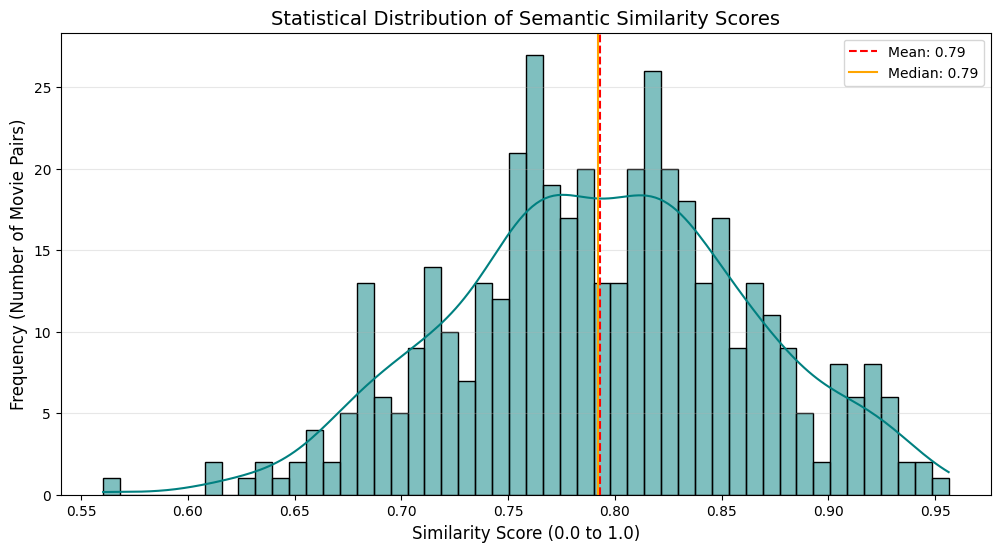

Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/similarity_score_summary.json


{'total_pairs': 435,
 'mean_similarity': 0.7930147126436782,
 'median_similarity': 0.7919,
 'standard_deviation': 0.06883538794917066,
 'minimum_similarity': 0.5603,
 'maximum_similarity': 0.9563}

In [11]:
similarity_score_summary = run_agent_tool(
    similarity_agent,
    "analyze_similarity_scores_tool",
    "Run analyze_similarity_scores_tool to analyze and visualize similarity score distribution.",
    checkpoint_name="similarity_score_summary",
)
similarity_score_summary


## 4h. Root Cause  Clustering based upon similarity score provided by user supplied cutoff value

In [12]:
filtered_pairs = run_agent_tool(
    clustering_agent,
    "filter_similarity_pairs_tool",
    "Run filter_similarity_pairs_tool with cutoff_value 0.92.",
    result_name="filtered_pairs",
    tool_kwargs={"cutoff_value": 0.92},
)


Pairs remaining after 0.92 cutoff: 15
Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/filtered_pairs.json


In [13]:
clusters = run_agent_tool(
    clustering_agent,
    "create_similarity_clusters_tool",
    "Run create_similarity_clusters_tool to create NetworkX connected-component clusters.",
    result_name="clusters",
)


Found 5 distinct clusters.
Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/clusters.json


In [14]:
cluster_summary = run_agent_tool(
    clustering_agent,
    "display_semantic_clusters_tool",
    "Run display_semantic_clusters_tool to print semantic clusters.",
    checkpoint_name="cluster_summary",
)
cluster_summary


--- SEMANTIC CLUSTERS (Cutoff: 0.92) ---

Cluster #1 (3 log files):
  - Log symptoms:  [{'id': 'symptom_job_completed_error', 'name': 'CloudBees job completed_error / error', 'description': 'Job f179cd8b-c3af-f13f-a937-4efb9ff91010 ended at 2026-07-07T06:38:05Z with status completed_error / error.'}, {'id': 'symptom_build_compile_failure_classification', 'name': 'Build outcome classified as Compile failure', 'description': 'The build failure reason was classified as Compile, although the RCA states this was consistent with inaccessible source files rather than a code defect.'}, {'id': 'symptom_VerifySrc_failed', 'name': 'VerifySrc step failed', 'description': 'The VerifySrc step failed during the job window on crm-ubuntu359 between 06:33:38Z and 06:34:50Z.'}, {'id': 'symptom_cifs_sesssetup_eacces', 'name': 'CIFS VFS SessSetup = -13 EACCES errors', 'description': 'Datadog flex logs recorded 69,624 CIFS VFS Send error in SessSetup = -13 entries targeting \\\\QCDFS.qualcomm.com between 20

{'cluster_count': 5, 'max_cluster_size': 7}

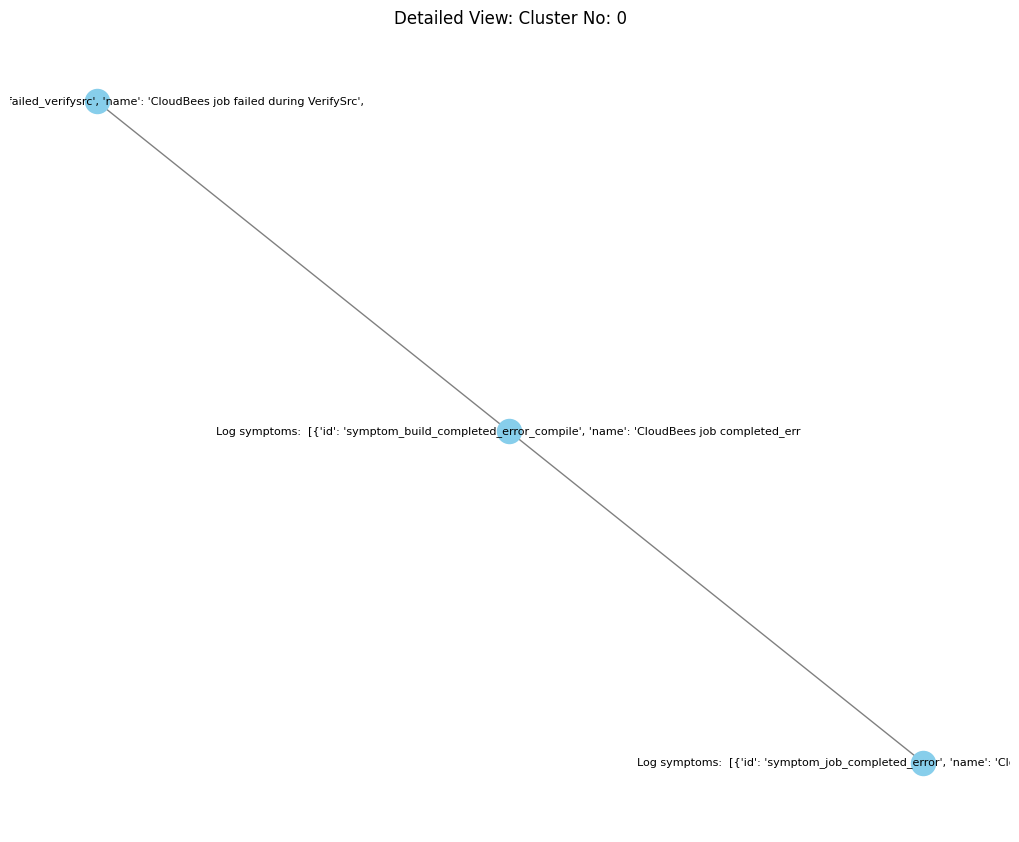

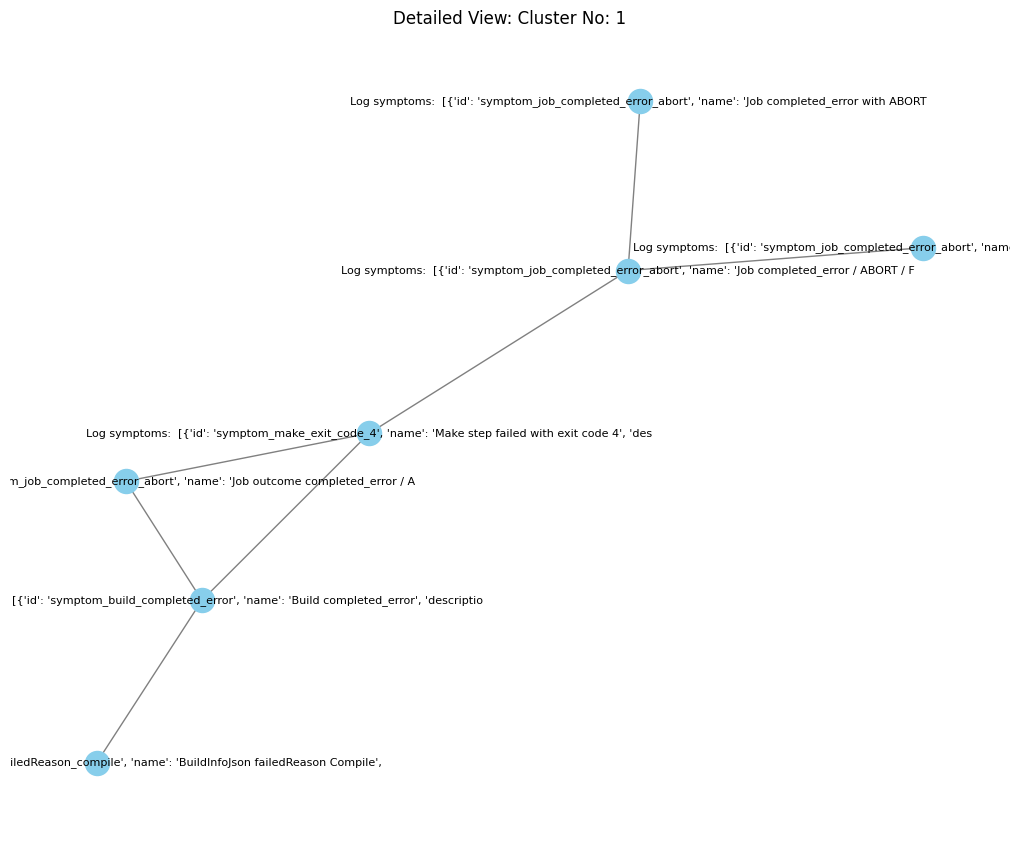

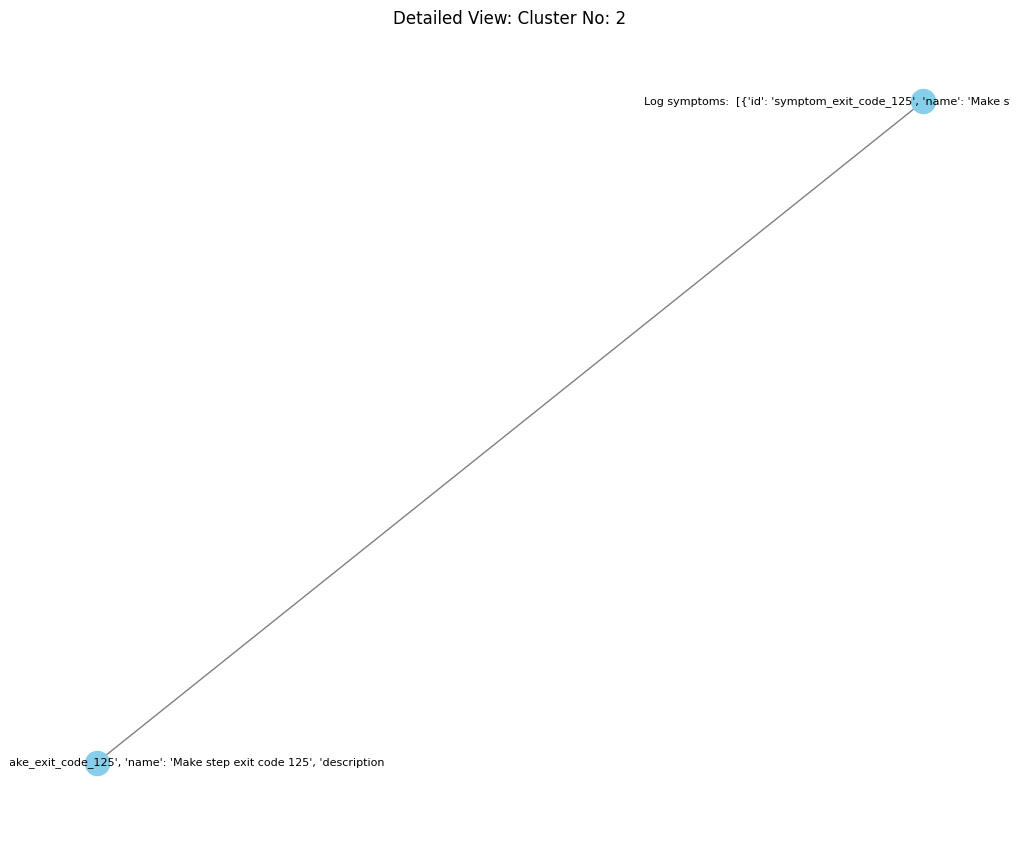

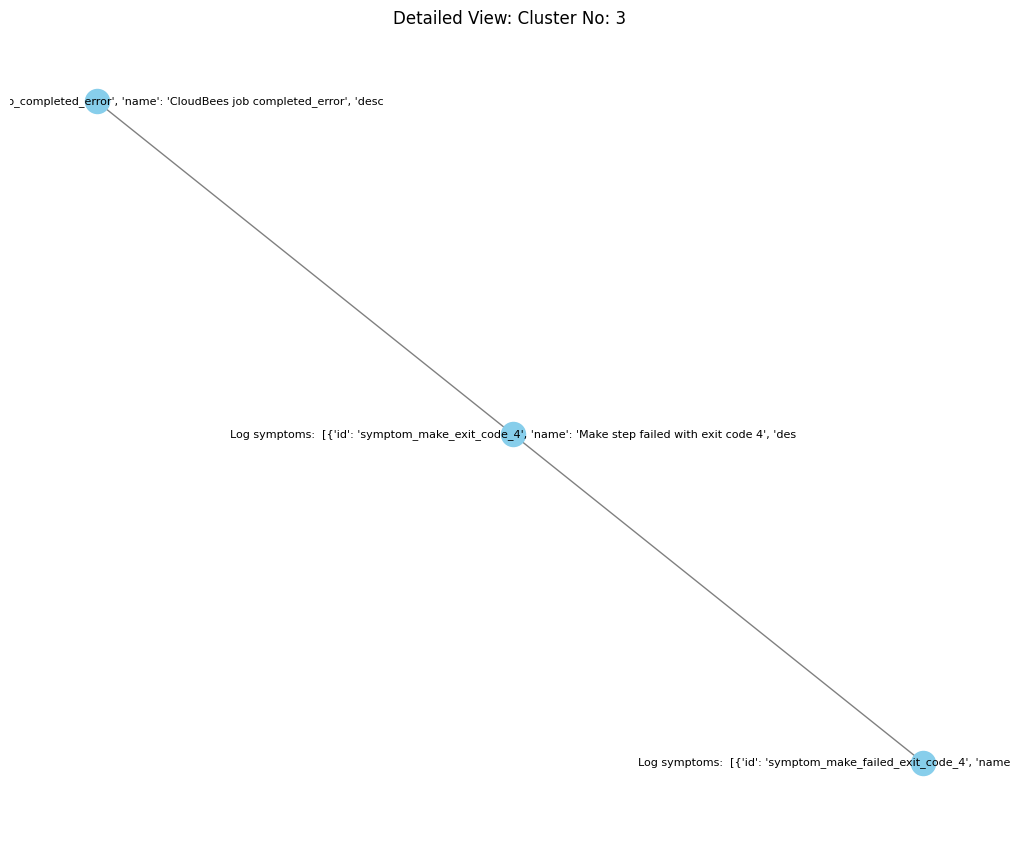

Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/visualize_clusters_response.json


In [15]:
visualize_clusters_response = run_agent_tool(
    clustering_agent,
    "visualize_similarity_clusters_tool",
    "Run visualize_similarity_clusters_tool with limit 4.",
    checkpoint_name="visualize_clusters_response",
    tool_kwargs={"limit": 4},
)


## 4i. Generating consistent Symptom, Root Cause and Data Gap for all nodes in a given cluster for all clusters

In [16]:
kg_records = run_agent_tool(
    kg_consistency_agent,
    "generate_consistent_cluster_srd_tool",
    "Run generate_consistent_cluster_srd_tool to build Pydantic-valid canonical KG records.",
    result_name="kg_records",
)


Generated 5 unique cluster KG records.
Generated 12 unmatched KG records.
Generated 17 total KG records.
Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/kg_records.json


## 4j. Saving JSON logs for all unique clusters and unmatched JSON logs as a knowledge Graph in the ChromaDB

In [17]:
kg_persistence_response = None
if USE_AGENT_RUN_FOR_TOOLS:
    kg_persistence_response = kg_persistence_agent.run(
        "Prepare to persist the Pydantic-valid RCA knowledge graph records into the configured Agno Knowledge object backed by ChromaDb."
    )
chroma_save_result = insert_knowledge_graph_records()
save_intermediate_result("chroma_save_result", chroma_save_result)
chroma_save_result


INFO Adding content from cluster_1

INFO Selecting reader for extension: Text

INFO Deleted 6 documents with content_hash 'a2e4a048f5099789ac79f8040885acf666b78f9f106f23da7f9ddd16125d0757'

INFO Upserting 6 documents

INFO Adding content from cluster_2

...

INFO Selecting reader for extension: Text

INFO Deleted 6 documents with content_hash '6f83ece34001e1db9bf7e6473d9d3e715afda43996844039fb4251e23961d3d3'

INFO Upserting 6 documents

{'knowledge_name': 'RCA Knowledge Graph', 'vector_db': 'ChromaDb', 'collection_name': 'rca_knowledge_graph', 'persist_directory': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/chroma_rca_kg', 'record_count': 17, 'record_ids': ['cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'unmatched_0', 'unmatched_3', 'unmatched_5', 'unmatched_10', 'unmatched_12', 'unmatched_13', 'unmatched_15', 'unmatched_16', 'unmatched_22', 'unmatched_23', 'unmatched_27', 'unmatched_29'], 'json_output_file': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/rca_knowledge_graph_records.json', 'document_schema': 'models.ExtractedRCA'}
Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/App

{'knowledge_name': 'RCA Knowledge Graph',
 'vector_db': 'ChromaDb',
 'collection_name': 'rca_knowledge_graph',
 'persist_directory': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/chroma_rca_kg',
 'record_count': 17,
 'record_ids': ['cluster_1',
  'cluster_2',
  'cluster_3',
  'cluster_4',
  'cluster_5',
  'unmatched_0',
  'unmatched_3',
  'unmatched_5',
  'unmatched_10',
  'unmatched_12',
  'unmatched_13',
  'unmatched_15',
  'unmatched_16',
  'unmatched_22',
  'unmatched_23',
  'unmatched_27',
  'unmatched_29'],
 'json_output_file': '/Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/rca_knowledge_graph_records.json',
 'document_schema': 'models.ExtractedRCA'}

In [22]:
with open(OUTPUT_FOLDER / "processed_rca_json_list.json") as json_file:
    processed_jsons = json.load(json_file)
processed_jsons


[{'file_name': 'RCA_f179d5bc-858d-f177-a3f1-4efb9ff91010.txt',
  'log_text': 'Build ID: f179d5bc-858d-f177-a3f1-4efb9ff91010  |  Generated: 2026-07-07\n\n---\n1. 📋 Executive Summary\nThe CloudBees CI build CI_WLAN.WBE.0.0-05065.1-QCAHKSWPL_SILICON-79 failed on 2026-07-07 due to a Compile Failure in the Make step. The build script wlan_build_lnx_wkk.sh / build.sh targeting 9224.wlanfw.eval_v2 image=wlan_halphy with CLANG_VER=10.0.0 exited with a non-zero code, triggering an abortJob cascade that also failed SaveBuild and cancelled all downstream steps. The CRM system\'s own BuildInfoJson explicitly records failedReason=Compile.\n\nA notable secondary observation is a memory anomaly on the agent host crm-ubuntulv20 (physical: las-colo12-h17-34): memory rose steadily by ~23 GB over 35 minutes during the Make step window (00:25–01:00 UTC), consistent with a large WLAN firmware compilation consuming increasing memory. This is expected behavior for a large CLANG-based firmware build and does

## 5. Pipeline 2: Run time Log analysis and remediation 

In [34]:
match_agent = Agent(
    name=match_row["agent_name"],
    model=model,
    output_schema=MatchResult,
    instructions=match_row["instructions"],
    retries=OPENAI_MAX_RETRIES,
    knowledge=rca_kg_knowledge,
    search_knowledge=True,
    delay_between_retries=5,
    exponential_backoff=True
)

In [20]:
new_log_files = run_agent_tool(
    ontology_loader_agent,
    "discover_new_logs_tool",
    "Run discover_new_logs_tool to discover new RCA log files.",
    result_name="new_log_files",
)

Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/new_log_files.json


In [28]:
new_jsons = run_agent_tool(
    historical_extraction_agent,
    "extract_new_rca_logs_tool",
    "Run extract_new_rca_logs_tool for all incoming new RCA logs.",
    result_name="new_jsons",
)


Saved intermediate result: /Users/nsathi/Library/CloudStorage/Dropbox/Applied AI Institute/Clients/Qualcomm/Neena-In-Progress/UseCases/UseCaseBuild/3-ChronousIQ/Log_Analysis_V7/notebook/KG_Construction_Pipeline/data/output/intermediate/new_jsons.json


In [30]:
new_jsons

[{'file_name': 'RCA_f1793408-9ec8-f1c3-a226-4efb9ff91010.txt',
  'log_text': "---\njob_id: f1793408-9ec8-f1c3-a226-4efb9ff91010\nchat_id: E3WE2M1H9NF2EPXCFYXM\ngenerated_at: 2026-07-07T19:59:41.372727\nsource: NOVA\npartial_response: False\n---\n\nI now have all the data I need to produce a comprehensive RCA report. The disk data is very revealing — the snap devices show 100% usage (which is normal for read-only snap mounts), the root filesystem `/` is at 52.5%, `/var` at 23.5%, and `/local/mnt` is at 3.1-3.9% and **rising** during the job window. The agent `crm-ubuntuhyd93` runs on physical host `hyd-d1952-d2-3-01` (Dell PowerEdge FC640). The `lastJobId` on `crm-ubuntuhyd93` at query time was `f1796842` — NOT the target job `f1793408`, confirming the job had already completed/failed by the time of the pool query at 12:14:09. The `stepCount=0` confirms no steps were running on the agent at that moment. The `GetCompilePackage` step was assigned to `crm-ubuntuhyd93` (agent ID `f0ec3f9f-f

In [36]:
for i in range(0,len(new_jsons)):
    match_response = None
    match_response = match_agent.run(
        f"New RCA JSON: {new_jsons[i]['log_json']}"
        )
    match_json = match_response.content.model_dump()
    print(json.dumps(match_json, indent=2))

INFO Found 10 documents

INFO Found 10 documents

INFO Found 10 documents

INFO Found 10 documents

{
  "matched_log_id": "log_rca_f179cb72",
  "match_score": 0.41,
  "confidence": "LOW",
  "explanation": "Closest historical match is RCA_f179cb72-2009-f120-bf77-2686f9881e6f.txt because it shares the generic graph pattern of a CloudBees CRMBuilds job ending completed_error/ABORT, an upstream transfer/dependency-oriented step aborting before natural completion, missing step stdout/stderr preventing exact trigger confirmation, and remediation focused on retrieving CloudBees step logs, checking remote endpoints, adding retry/timeout handling, and improving log forwarding. The match is weak: no processed RCA found with the exact DistributeBuildToRemote.Rel.521730 procedure, GetCompilePackage, DownloadInRemoteSite, PCM Web Service, crm-ubuntuhyd93, or hyd-d1952-d2-3-01 nodes. The closest match also attributes the failure to outbound transfer/IO pressure, while the new RCA points to a probable GetCompilePackage step-level abort with healthy infrastructure and unconfirmed PCM/artifact depend

...

{
  "matched_log_id": "unmatched_0 / RCA_f179d5bc-858d-f177-a3f1-4efb9ff91010.txt",
  "match_score": 0.74,
  "confidence": "MEDIUM",
  "explanation": "Best match is the prior WLAN firmware compile-failure RCA in unmatched_0. Strong overlapping graph evidence: same CloudBees procedure Build.Rel.602829, failed Make compile/build step, non-zero/exit-code-4-style Make failure, BuildInfoJson failedReason=Compile, abortJob cascade affecting SaveBuild/downstream steps, healthy Commander/setup context, missing Make execution log as a key data gap, and remediation emphasis on retrieving Make logs and identifying compiler diagnostics. Match is not HIGH because the new RCA is for WLAN HSP 6490 eval_v1/eval_v2 on crm-ubuntulv57/las-colo12-h19-20 and includes confirmed 0-byte disk exhaustion as a plausible contributor, while the matched prior RCA is WLAN WBE 9224 on crm-ubuntulv20/las-colo12-h17-34 and assessed infrastructure as not causal. Node occurrence counts incremented for shared nodes/classe

INFO Found 10 documents

INFO Found 10 documents

INFO Found 10 documents

{
  "matched_log_id": "log_rca_f179c9e2",
  "match_score": 0.66,
  "confidence": "MEDIUM",
  "explanation": "Best match is RCA_f179c9e2-7f0b-f109-a3ba-1ea035bf3243.txt. The strongest shared graph pattern is CRMBuilds / Build.Rel.602829 -> Make compile failure -> failedReason=Compile -> job completed_error/error with missing exact compiler output -> remediation to retrieve Make logs. Both records also use Datadog host telemetry to identify a likely infrastructure contributor during compilation and have absent application/step logs. The match is not HIGH because the prior RCA's infrastructure contributor is network/IO contention on san-w175-ma3-2-05 with Make exit code 4, while the new RCA's contributor is severe memory pressure on san-w175-ma3-1-05 and the exact Make exit code/compiler diagnostic is unknown. Recurring node/relationship occurrence counts were incremented for: Build.Rel.602829, Make, Compile, failedReason=Compile, Make-failure indicates compile root cause, missing Make lo